In [1]:
import numpy as np
import scipy as sp
import scipy.signal as signal
import matplotlib
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.ar_model import AutoReg
# you may need to first run conda install plotly
import plotly
import plotly.graph_objects as go

# Lecture 7: Introduction to stochastic processes

- Simple random processes and “white noise”.

- Stationarity, expectation, variance and co-variance

- Random walks, Brownian motion and “autoregressive” noise models.


Textbook: chapters 3 and 6 of Chris Chatfield, “The Analysis of Time Series: An Introduction” (6th Edition), Chapman and Hall, 2003. This is an excellent practical book for whatever you plan to do next, from MPhys projects to financial forecasting.

#### 7.1 Stochastic processes: 

You’ve heard how apparently unpredictable, random-looking behaviour can arise in low-dimensional deterministic chaotic systems like the quadratic map or the Lorenz '63 system of ODEs. In both cases, understanding the mathematics of the generating process revealed interesting things about it:
- How the changing stability of $n$-orbits leads to period-doubling in the quadratic map.
- Volume contraction in the Lorenz system showing it must occupy a less-than-3-dimensional attractor.
- Poincare-Bendixon theorem showing a non-repeating orbit must occupy a greater-than-2-dimensional attractor.


But we are ultimately interested in things we can observe, not just the behaviour of interesting sets of equations. Before concluding some random-looking behaviour has been generated by deterministic chaos, we have to understand what else might have generated it.

Most of the systems you will actually encounter will be much easier to characterise as linear stochastic processes than low-dimensional chaos. The theory of linear stochastic processes provides the basic workhorse tools for time-series analysis and most practical prediction.

#### 7.2 An archetypal random process:

Let's start by considering the model

$$ x_{t+\delta t} = x_{t} + P \delta t \; \epsilon_t  $$

where 

$$ \epsilon_t \sim N(0,\sigma_{\epsilon}^2) $$

(the symbol $\sim$ meaning "is distributed as") is a discrete sequence of normally distributed random shocks with zero mean and variance $\sigma_{\epsilon}^2$.

If $P$ being the probability per unit time of a shock occurring and $\delta t$ is sufficiently small that there is almost no chance of two shocks occurring in any time-interval, then $P \delta t$  is a random process that has a certain probability of being $1$ in a given time interval, and is $0$ otherwise.  

#### 7.2 An archetypal random process:

Try varying the time plotted (tplt): note that the aspect ratio of the plot is kept constant at unity.

Notice how the appearance of the plot changes as we zoom in: this is *not* a self-similar process.

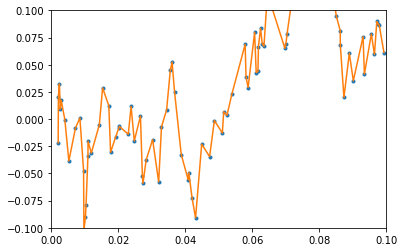

In [2]:
tmax=1000.
vmax=1000.
ndis=1000000
# set the standard deviation of individual shocks
sdis=np.sqrt(vmax/ndis)
# define times at which ndis shocks occur
t=np.random.uniform(0.,tmax,ndis)
# order them
t=np.sort(t)
# accumulate the impact of shocks
x=np.cumsum(np.random.normal(0.,sdis,ndis))
# define plotting interval (also defines the yscale)
tplt=0.1
iplt=np.where(t < tplt)
plt.plot(t[iplt],x[iplt],'.')
plt.plot(t[iplt],x[iplt])
plt.xlim(0,tplt)
plt.ylim(-tplt*vmax/tmax,tplt*vmax/tmax);

#### 7.3 The Discrete Random Walk:

Although plausible-looking, this model is difficult to work with because it has two random elements: whether or not a shock occurs in any given time interval, and how large that shock is. The way we have defined it, it is also not regularly sampled.

In the limit $P \delta t \gg 1$ many shocks are almost certain to occur in any given sampling interval, so we can simplify. The variance of the  sum of the shocks in a given time interval $\delta t$ scales with their number, $P \delta t$, so the model becomes

$$ x_{t+\delta t} = x_{t} + \alpha \sqrt{\delta t} \; z_t $$ 

where $z_t \sim N(0,1)$ is a series of uncorrelated, unit-variance, normally-distributed random numbers, sometimes known as "white noise", and $\alpha^2 = P \sigma_{\epsilon}^2$. 

#### 7.4 Some definitions: 

- Expected value of $x$, $\langle x \rangle =$ the mean of an infinite sequence of realisations of $x$.

- Variance of a scalar: $\langle x^2 \rangle$

- Covariance between two scalars: $\langle x \, y \rangle$

- Expectation of an element of a vector: ${\langle {\bf{x}} \rangle}_i = \langle x_i \rangle$

- Covariance (matrix) between two  vectors: ${\bf{C}}_{{\bf{x}} {\bf{y}}} = {\langle {\bf{x}} {\bf{y}}^T \rangle}$

- Lag-covariance of a time-series $x_t$ at lag $k$: $c_k=\langle x_t \, x_{t+k} \rangle$

#### 7.5 Properties of "white noise":

A discrete white noise process $z_t$ has some useful properties:

\begin{eqnarray*} \langle z_t \rangle & = & 0 \;\; \mbox{(zero mean)}\\
                  \langle {z_t}^2 \rangle & = & 1 \;\; \mbox{(unit variance)}\\
                  \langle z_t y_t \rangle & = & 0 \end{eqnarray*}
                  
where $y_t$ is *any* process which does not depend on $z_t$. 

#### 7.6 Discrete versus continuous processes:

Back to the model:

$$ x_{t+\delta t} = x_{t} + \alpha \sqrt{\delta t} \; z_t . $$

Notice how strange things happen if we try and write the random walk model as a differential equation:

$$ \frac{\delta x}{\delta t} = \frac {\alpha \, z_t}{\sqrt{\delta t}} \;\; , $$

$ $which tends to infinity as $\delta t \rightarrow 0$. There is a fundamental sense in which stochastic processes are intrinsically discrete: perhaps this is one of the reasons Einstein had such difficulties with randomness in quantum mechanics, because it seems to conflict with the notion of a continuous universe.

#### 7.7 Brownian motion:

The variance of the displacement between the start and end points of a random walk is just the expected square on the sum of the disturbances, which increases linearly with the number of steps. Hence a random walk is non-stationary, since its moments (mean, variance etc.) do not converge in the limit $t \rightarrow \infty$. To obtain as stationary process, one additional ingredient is needed:

$$ x_{t+\delta t} = x_{t} + P \delta t \; ( \epsilon_t - \mu x_t ) \;\; . $$

Or in the long-sampling-interval limit

$$ x_{t+\delta t} = (1 - \gamma \delta t) x_{t} + \alpha \sqrt{\delta t} \; z_t \;\; , $$

where $\gamma = P \mu$. If $x_t$ describes the *velocity* of a particle undergoing Brownian motion, what is the physical significance of $\mu$?

#### 7.8 Simple autoregressive processes:

Simplifying notation of the model of Brownian motion

$$ x_{t} = a_1 x_{t-1} + a_0 z_t , $$

where $z_t$ is a unit-variance white noise process and the $a_i$ are process coefficients. 

You can of course re-write this as 

$$ - a_1 x_{t-1} + x_{t} = a_0 z_t , $$

which is why Python statsmodels defines AR coefficients as $\left[-a_p,...,1\right]$ (back to this later).

The AR(1) process is the simplest physically plausible model of variability in almost all data-analysis problems involving regular sampling of a continuous system.  

#### 7.9 Properties of an AR(1) process

The governing equation of an AR(1) process:
$$ x_t = a_0 z_t + a_1 x_{t-1} $$

We compute expected lag-covariances, $c_k \equiv \langle x_{t-k} x_t\rangle$, *assuming* the process is stationary with zero mean, by pre-multiplying by the various random sequences in equation (1) and taking expectations:
$$ \langle z_t x_t\rangle  = a_0 \langle z_t z_t\rangle  + a_1 \langle z_t x_{t-1}\rangle  = a_0 $$

$$ c_0 = \langle x_t x_t\rangle  = a_0 \langle x_t z_t\rangle  + a_1 \langle x_t x_{t-1}\rangle  = {a_0}^2 + a_1 c_1 $$

$$ c_1 = \langle x_{t-1} x_t\rangle  = a_0 \langle x_{t-1} z_t\rangle  + a_1 \langle x_{t-1} x_{t-1}\rangle  = a_1 c_0  $$

$$ c_k = \langle x_{t-k} x_t\rangle  = a_0 \langle x_{t-k} z_t\rangle  + a_1 \langle x_{t-k} x_{t-1}\rangle  = a_1
c_{k-1} \;\; .  $$

$$ c_0 = \frac{{a_0}^2}{1-{a_1}^2} $$

$$ c_k = c_0 {a_1}^k . $$

Theoretical and actual variance: 5.263157894736843 5.314422759885591


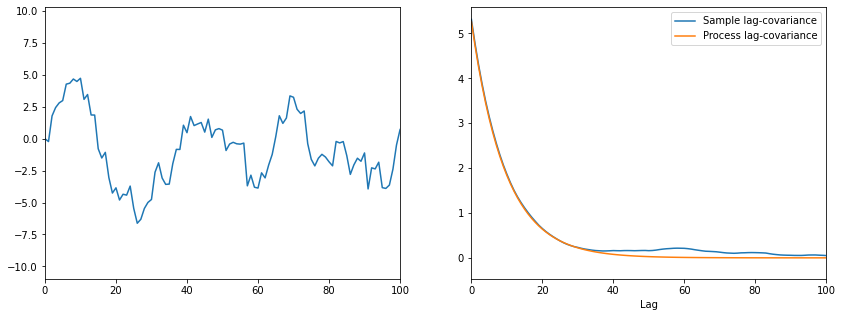

In [3]:
a=np.array([1.0,0.9])
ndis=100000
t1=np.arange(ndis)
z1=np.random.normal(0.,1.,ndis)
x1=np.zeros_like(z1)
for i in range(1,ndis): 
    x1[i]=a[0]*z1[i]+a[1]*x1[i-1]
c_k=(a[0]**2/(1.-a[1]**2))*a[1]**t1 # This is where we derive the process lag-covariance
acv=np.convolve(x1,x1[::-1])/ndis # This is where we estimate the lag-covariance from the sample of process output
print('Theoretical and actual variance:',c_k[0],np.var(x1))
plt.figure(figsize=(14,5))
plt.subplot(1,2,1)
plt.plot(t1,x1)
plt.xlim(0,100)
plt.subplot(1,2,2)
plt.plot(t1,acv[ndis-1:],label='Sample lag-covariance')
plt.plot(t1,c_k,label='Process lag-covariance')
plt.xlim(-0.1,100)
plt.xlabel('Lag')
plt.legend();

#### Exercise: 

Sketch $c(k)$ for an AR(1) process in which (i) $a_0 = 2$, $a_1 = 0.8$; (ii) $a_0 = 2, a_1 = 0.3$; and (iii) $a_0 = 2, a_1=-0.8$. 

#### 7.10 The AR(p) Process

The obvious generalisation of the AR(1) process is the AR($p$) process

$$ x_t = a_0 z_t + a_1 x_{t-1} + a_2 x_{t-2} + \ldots + a_p x_{t-p} . $$

Multiplying both sides by $z_t$ and $x_{t-k: k=1, p}$ and taking expectations gives $p+1$ simultaneous equations relating lag-covariances $c_k$ and the process coefficients $a_i$. These are known as the ''Yule-Walker'' equations:

$$ \begin{eqnarray} c_0 & = & \sum_{i=1}^{p} a_i c_{i} + a_0^2 \\
c_k & = & \sum_{i=1}^{p} a_i c_{k-i} \;\; \mbox{for} \;\; k=1, p. \end{eqnarray} $$

These allow us to estimate the $c_k$ by observing process output, and hence derive the process coefficients. 
The crucial implication is that if you know $c_0$ to $c_p$ for an AR($p$) process, you can derive the process coefficients and hence *all there is to know* about it.  This is *not* true of non-linear processes.

#### 7.10b More on the AR(p) Process

While any individual realisation of an AR($p$) process is random, the process lag-covariance $c_k$ is not, and we can estimate it by taking successive realisations of the process, or chunks of the same realisation, and convolving them with each other. We can also use it to understand the properties of an AR($p$) process. Writing the Yule-Walker equations for $c_k$ where $k \ge 1$ in matrix-vector form

$$ {\bf c}_k = {\bf A} {\bf c}_{k-1} $$

where ${\bf c}_k$ is the vector $[c_k,c_{k-1},c_{k-2},...]$ the top row of ${\bf A}$ are the coefficients $a_1$ to $a_p$ and all other coefficients are zero apart from 1s in the first lower off-diagonal (check!). 

Successive application this recursive equation yields:

$$ {\bf c}_k = {\bf A}^k {\bf c}_{0} $$

Writing ${\bf A}$ in terms of its eigenvalues and eigenvectors:

$$ {\bf A} = {\bf E} {\bf \Lambda} {\bf E}^{-1} \mbox{  and  } {\bf A}^k = {\bf E} {\bf \Lambda}^k {\bf E}^{-1} $$

so 

$$c_k = \sum_{i=1}^p \epsilon_i \lambda_i^k = \sum_{i=1}^p \epsilon_i \exp(k \ln(\lambda_i))$$

Hence if any $|\lambda_i| \gt 1$ (bearing in mind the $\lambda_i$ may be complex), the covariance diverges for large $k$ and the process is unstable.


#### 7.11 Other linear models:

A ''moving average'', MA($q$), process is defined by

$$ x_t = b_0 z_t + b_1 z_{t-1} + \ldots + b_q z_{t-q} . $$

An autoregressive process can always be expressed as a (possibly infinite order) moving average process and *vice versa*, so we typically use whichever provides the most compact representation of our data. 

For completeness, we should mention the autoregressive-moving-average process, ARMA($p$,$q$):

$$ \begin{eqnarray} x_t & = & b_0 z_t + b_1 z_{t-1} + \ldots + b_q z_{t-q} \\
        &   & + a_1 x_{t-1} + \ldots + a_p x_{t-p}. \end{eqnarray} $$
        
You should understand lag-covariances and power spectra (see later) of simple AR and MA processes, but not ARMA or more complicated models.

#### Another exercise:

Compute $c_k$ for an MA($q$) process with all $b_k=1/(q+1)$ (a.k.a. a simple running mean). What is the main qualitative difference between $c_k$ for an AR($p$) process and $c_k$ for an MA($q$) process, where both $p$ and $q$ are relatively small?

#### 7.12 Power Spectral Analysis.

The commonest method of analysing linear stochastic processes is by examining at their power spectra. This makes sense because the power spectrum contains all there is to know about a linear stochastic process. It does not contain all there is to know about a non-linear process.

This is why you need to be careful with power spectra: the justification of interpreting data in terms of a power spectrum is deeply rooted in the linear stochastic model. If that model is physically inappropriate to the system you are examining, the power spectrum can be deeply misleading.

#### 7.13 What is the Power Spectrum? 
As the name implies, the power spectrum of a process $x_t$ is the expected power, or variance, as a function of frequency:

$$ h(\omega) = \langle | \sum_{k=0}^{M-1} x_{t+k} e^{i\omega k} |^2 \rangle $$

*If* the process is stationary, we can estimate the power spectrum by averaging over lots of segments of process output, each of length $M$:

$$ \widetilde{h}(\omega) = \frac{1}{N-M+1} \sum_{t=1}^{N-M+1} | \sum_{k=0}^{M-1} x_{t+k} e^{i\omega k} |^2 $$

This is approximately equal to

$$ \widehat{h}(\omega) =  \sum_{k=-M}^{M} w_k \hat{c}_k e^{i\omega k} $$

where $\widehat{c}_k$ is the estimated lag-$k$ covariance, and $w_k$ is a vector of weights

$$ \widehat{c}_k = \frac{1}{N-k} \sum_{t=1}^{N-k} x_t x_{t+k} . $$

#### 7.14 Estimating power spectra

$w_k$ is a symmetric "weighting function" which is unity at $k=0$ and tapers off to zero for $|k|>M$. Lots of weighting functions have been proposed, and statisticians get exercised about which are best, but it doesn't seem to make that much difference in most applications.

This is an application of the *correlation theorem*, which states that the Fourier transform of the cross-covariance of two series is equal (give or take a normalisation) to the product of the Fourier transform of one series with the complex conjugate of the Fourier transform of the other:

$$ (x_t \star y_t)(k) \equiv \int x_t y_{t+k} dt $$
$$ {\cal F}(x_t \star y_t) = {\cal F}^\ast(x_t) {\cal F}(y_t) $$

Note that the lag-covariance $c_k$ is the cross-covariance of $x_t$ with itself. So the power spectrum and the lag-covariance function are essentially two ways of displaying the same information. 

#### 7.15 The spectrum of an AR(p) process:

$$ h(\omega)_{\mbox{AR($p$)}} = 
\frac{a_0^2}{|1 - a_1 e^{-i\omega} - a_2 e^{-2i\omega} - \ldots |^2} . $$

Given that the covariance function $c_k$ for an AR($p$) process was defined implicitly through the Yule-Walker equations, this may seem astonishingly simple. The proof is rather involved, you don't need to prove it, or even remember it (although you might like to think about some special cases for low-order AR models).

#### Exercise:

Show that for a random walk ($a_1 = 1$, all higher terms zero), $h(\omega) = a_0^2 \omega^{-2}$ as $\omega \rightarrow 0$: this $-2$ "power law" behaviour emerging in the high-frequency limit is a hall-mark of random-walk-type processes.


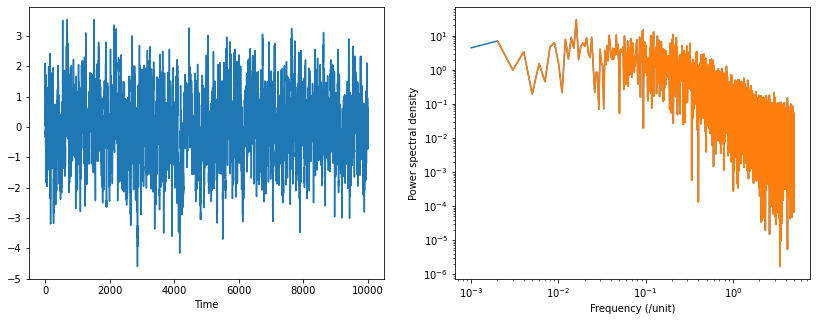

In [4]:
nds = 10000
a = np.array([0.5, 0.9]) # AR coefficients
ds=0.1
ar = -a # insert unit coeff @ zero-lag and negate to get the syntax of arma_generate inputs
ar[0] = 1 
ma = np.array([a[0],0]) # MA coefficients, including zero-lag
y_s = sm.tsa.arma_generate_sample(ar, ma, nds)
fry, psy = signal.periodogram(y_s, 1./ds)
fft = np.fft.fft(y_s) # doing it explicitly so you can see what signal.periodogram is up to 
psd = np.real(fft*np.conjugate(fft))[1:int(nds/2+1)]*2.*ds/nds
frq = (1.+np.arange(nds/2))/nds/ds
plt.figure(figsize=(14,5))
plt.subplot(1,2,1)
plt.plot(np.arange(nds), y_s)
plt.xlabel('Time')
plt.subplot(1,2,2)
plt.plot(fry[1:], psy[1:])
plt.plot(frq[1:], psd[1:])
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Frequency (/unit)')
plt.ylabel('Power spectral density');

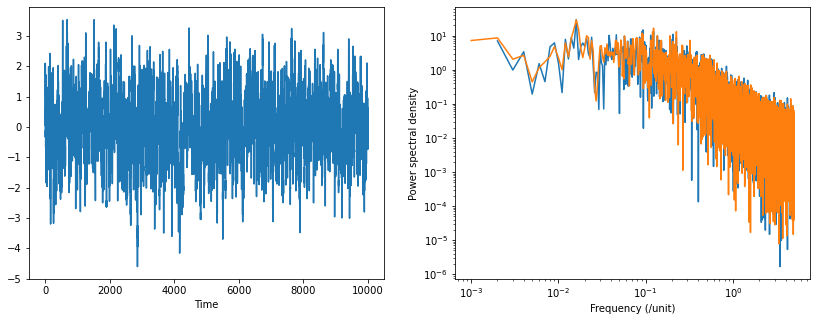

In [5]:
nfft = 10000
fry, psy = signal.periodogram(y_s, 1./ds, "bartlett", nfft)
for n in range(np.int(nds/nfft)):
    fry, psy_n = signal.periodogram(y_s[n*nfft:(n+1)*nfft], 1./ds, "bartlett", nfft)
    psy += psy_n
psy=psy/np.int(nds/nfft)
plt.figure(figsize=(14,5))
plt.subplot(1,2,1)
plt.plot(np.arange(nds), y_s)
plt.xlabel('Time')
plt.subplot(1,2,2)
plt.plot(frq[1:], psd[1:])
plt.plot(fry[1:], psy[1:]/2)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Frequency (/unit)')
plt.ylabel('Power spectral density');

#### 7.16 Distinguishing low-dimensional chaos from a stochastic process:
This example is based on Mat Easton's MPhys project in 2005. We begin with the $z$ component of the Lorenz (1963) system:

\begin{eqnarray*}
\dot{x} & = \sigma(y-x) \\
\dot{y} & = \rho x - y - xz \\
\dot{z} & = -\beta z + xy
\end{eqnarray*}

In [6]:
## define the Lorenz '63 system:
def L63(X, t, r, s, b):
    x, y, z = X  # Unpack the state vector
    return s * (y - x), x * (r - z) - y, x * y - b * z
## define the Lorenz '63 Jacobian:
def L63_J(X, r, s, b):
    x, y, z = X  # Unpack the state vector
    return np.array([ [ -s , s , 0 ],[ r - z , -1 , -x ],[ y , x , -b ] ])
## Specify model parameters:
s, r, b = [10, 28, 8/3]
## Specify integration time and timestep:
dt = 0.01
int_time = 1000.
t = np.arange( 0 , int_time , dt )
I = np.identity(3)
## Specify initial conditions
X0 = [0.1 , 0.1 , 5]

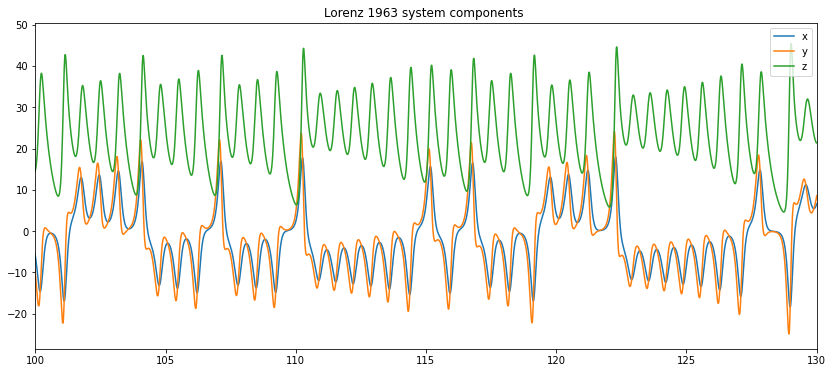

In [7]:
X = sp.integrate.odeint(L63, X0, t, args=(r,s,b))
plt.figure(figsize=(14,6))
llab=['x','y','z']
nplt=int(200/dt)
for i in range(0,3):
    plt.plot(t[0:nplt], X[0:nplt,i], label=llab[i])
plt.xlim([100,130])
plt.legend()
plt.title('Lorenz 1963 system components ');

#### Suppose all we have is the $z$-component of the Lorenz system

We'll also assume it is sampled every 0.1 Lorenz "days", but also assume our "observations" are noise-free.

The first thing we notice is that the data is not normally distributed: but this does not mean it has been generated by a non-linear process, because the observing system might have been non-linear.

We can rescale ("histogram renormalise") the Lorenz output to force it to conform to a Gaussian distribution.
This does not affect the underlying dynamics, because the re-scaling, although non-linear, is invertible.

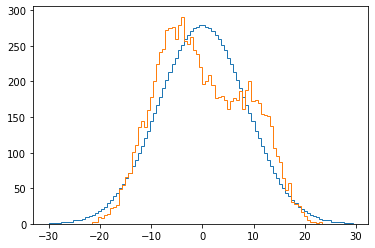

In [8]:
ds=0.1
z_s=X[0::int(ds/dt),2]-np.mean(X[0::int(ds/dt),2])
nds=z_s.size
i_z=np.argsort(z_s)
z_n=np.copy(z_s)
z_n[i_z]=sp.stats.norm.ppf((np.arange(nds)+0.5)/nds, 0., np.std(z_s)).flatten() # equate with corresponding element of normal cdf
nbin=100
hran=np.array([-30.,30])
ibn=hran[0]+np.arange(nbin)*(hran[1]-hran[0])/nbin
plt.hist(z_n,bins=ibn,histtype='step');
plt.hist(z_s,bins=ibn,histtype='step');

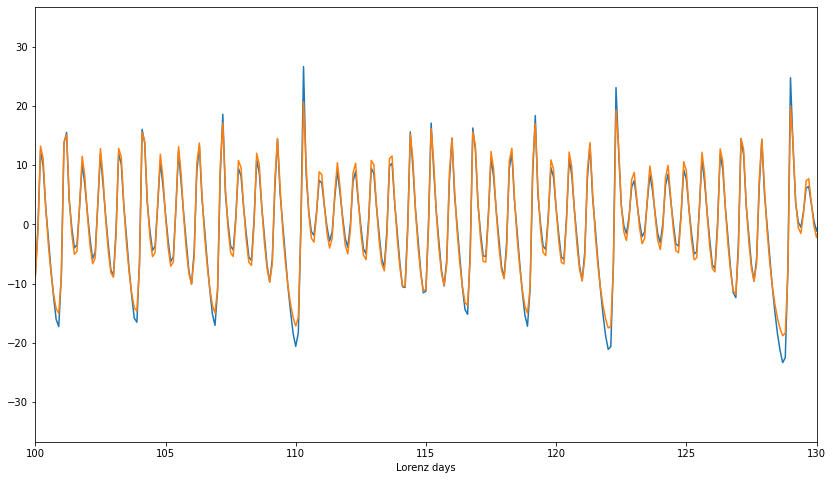

In [9]:
t_s=t[0::int(ds/dt)]
plt.figure(figsize=(14,8))
plt.plot(t_s[0:nplt],z_n[0:nplt])
plt.plot(t_s[0:nplt],z_s[0:nplt])
plt.xlim([100,130])
plt.xlabel('Lorenz days');

#### What about the power spectrum?

We'll compute a simple "periodogram" -- the crudest power spectral estimate, with no smoothing or averaging to get rid of noise.

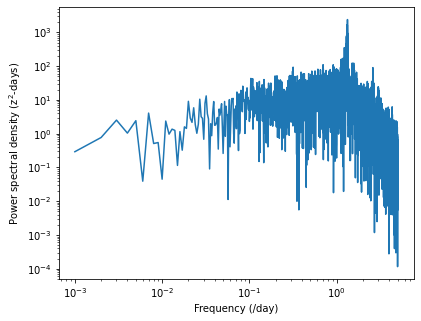

In [10]:
frz, psz = signal.periodogram(z_n, 1./ds) # calculate psd using scipy signal processing
plt.figure(figsize=(14,5))
plt.subplot(1,2,1)
plt.plot(frz[1:], psz[1:], label='Periodogram')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Frequency (/day)')
plt.ylabel('Power spectral density (z$^2$-days)');

#### An AR(p) model of the Lorenz output

We estimate the process coefficients of the AR model by solving the Yule-Walker equations (needless-to-say, there is plenty of code available to help you do this with Python: but it's a good idea to think about what you are doing, and not use these tools as black boxes).

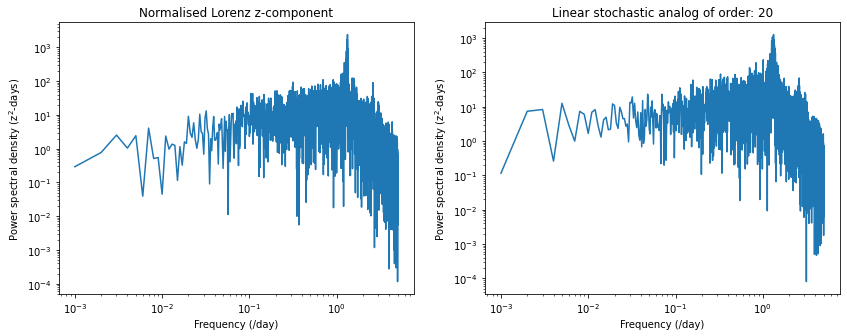

In [11]:
aro = 20 # Set order of AR model
rho, sigma = sm.regression.yule_walker(z_n,order=aro); # Estimate AR(p) process coefficients
ar = np.r_[1, -rho] # add zero-lag and negate
ma = np.r_[1, 0]    # add zero-lag, no moving average term
y_s = sm.tsa.arma_generate_sample(ar, ma, nds, scale=sigma)
fry, psy = signal.periodogram(y_s, 1./ds)
plt.figure(figsize=(14,5))
for i in range(0,2):
    plt.subplot(1,2,i+1)
    if i == 0: 
        plt.plot(frz[1:], psz[1:], label='Periodogram')
        plt.title('Normalised Lorenz z-component')
    else:
        plt.plot(fry[1:], psy[1:], label='AR sample')
        plt.title('Linear stochastic analog of order: '+str(aro))
    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel('Frequency (/day)')
    plt.ylabel('Power spectral density (z$^2$-days)');

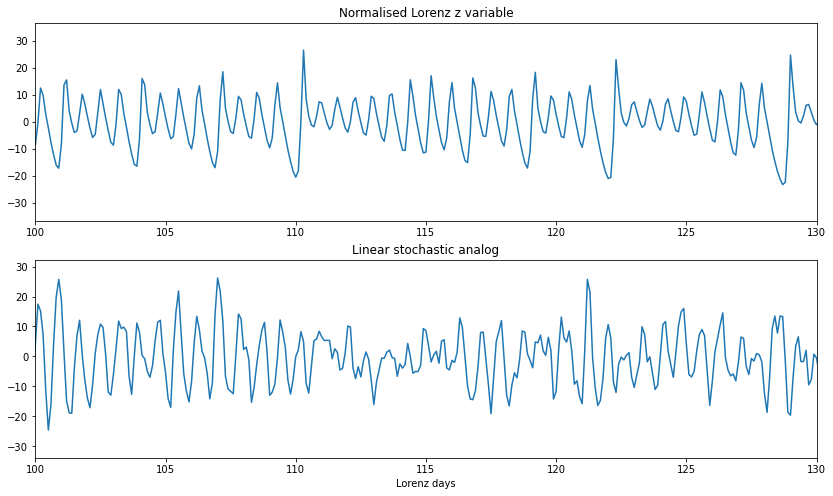

In [12]:
plt.figure(figsize=(14,8))
plt.subplot(2,1,1)
plt.plot(t_s,z_n)
plt.title('Normalised Lorenz z variable')
plt.xlim([100,130])
plt.subplot(2,1,2)
plt.plot(t_s,y_s)
plt.title('Linear stochastic analog')
plt.xlim([100,130])
plt.xlabel('Lorenz days');

#### 7.17 The Lorenz Map

The simplest way of showing the dynamics of the Lorenz system are restricted in a way you would not expect from the equivalent linear stochastic process is the Lorenz Map, which plots successive local maxima in $z$ against each other, which gives something close to a well-defined curve (it’s well-defined, just not a curve). If you do the same with the linear process output, you get a mess. But this only works because the Lorenz attractor is very close to flat: we need a more general approach, which we will discuss tomorrow.

In [13]:
def maxplot(z_s,t_s):
    ds=t_s[1]-t_s[0]
    nds=t_s.size
    dzdt = (z_s[1:]-z_s[0:nds-1])/ds
    lst = []
    for i in range(1,nds-1):
        if dzdt[i-1] > 0 and dzdt[i] < 0: lst.append(i)
    lst=np.array(lst)
    plt.figure(figsize=(14,4))
    plt.subplot(1,2,1)
    plt.plot(t_s,z_s)
    plt.title('Series maxima')
    plt.plot(t_s[lst],z_s[lst],'ro')
    plt.xlim([100,130]);
    plt.subplot(1,2,2)
    plt.title('Series maxima')
    plt.plot(z_s[lst[0:lst.size-1]],z_s[lst[1:lst.size]],'ro')
    plt.xlabel('n th maximum')
    plt.ylabel('n+1 th maximum');

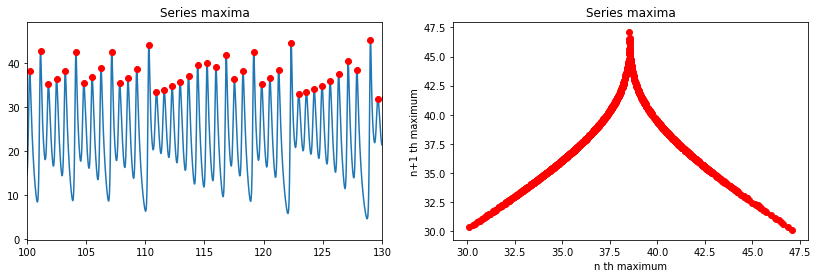

In [14]:
z=X[:,2]
maxplot(z,t)

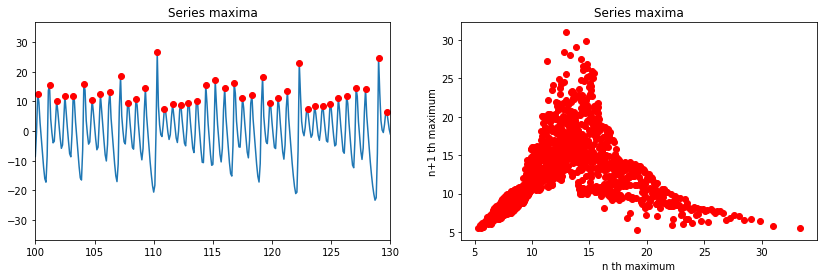

In [15]:
maxplot(z_n,t_s)

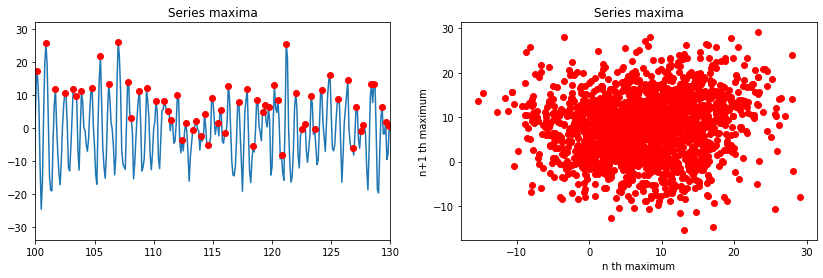

In [16]:
maxplot(y_s,t_s)

#### Mat Easton's MPhys project

What Mat Easton did was to convert these signals into audible sounds, put the wav files  up on the web and asked people to spot the odd one out. Despite most people claiming they couldn't tell the difference and had to guess, a very significant percentage got the answer right, with (self-styled) musicians doing significantly better than non-musicians.

This was intriguing for physiologists, because our standard understanding of how the ear works is that different little hairs in some coiled-up-tube-things detect different frequencies, but these chaotic and stochastic signals had identical power at all frequencies. 

Hence the ear must be able to detect consistent sub-millisecond phase-relationships between different frequencies, which is one of the hallmarks of low-dimensional chaos. 